# Histogram: nghiên cứu baseline và mô hình cuối đã khóa

Chạy tất cả các cell từ trên xuống dưới. Notebook gọi các hàm xử lý của project
từ `src/`; không cài đặt lại thuật toán Histogram.

- **A. Baseline / nghiên cứu:** giữ lại kết quả huấn luyện cơ sở ở BƯỚC 9
  để giải thích đặc trưng, Histogram, làm mượt, chọn đỉnh và ngưỡng.
- **B. Thử nghiệm tham số:** đọc kết quả so sánh đã lưu, chỉ từ tập huấn luyện.
- **C. Mô hình cuối đã khóa:** nạp cùng cấu hình và ngưỡng mà `main.py` sử dụng.
- **D. Trực quan hóa cuối:** dự đoán trên tập huấn luyện bằng mô hình đã khóa.

Nguồn chuẩn cho kết quả cuối là
`output/training/final_histogram_configuration.json`.
Kết quả baseline nằm trong `output/training/histogram_training_report.json`
và được ghi nhãn riêng; ngưỡng baseline không phải ngưỡng dùng khi demo cuối.

Cài thư viện bằng `python -m pip install -r requirements-notebook.txt`
và chọn kernel Python của môi trường project. Notebook chỉ đọc dữ liệu
huấn luyện và các báo cáo đã lưu; không đọc WAV/LAB kiểm thử, không chạy lại
tìm kiếm tham số và không ghi đè mô hình hay báo cáo huấn luyện.


## A. Baseline / nghiên cứu — kết quả lịch sử

### 1. Import thư viện và module của project

Xác định thư mục gốc của project và import các hàm xử lý đã cài đặt.
Các đồ thị trong notebook phục vụ nghiên cứu; notebook không định nghĩa lại
các hàm xử lý tín hiệu hoặc thuật toán Histogram.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import Markdown, display

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/segmentation/histogram.py").is_file()
             and (p / "data/tinhieuhuanluyen").is_dir()), None)
if root is None:
    raise FileNotFoundError("Hãy mở pipeline.ipynb bên trong project XLTHS_GK.")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

from src.config import Config, load_frozen_histogram
from src.models import Threshold, SegmentationResult
from src.audio.loader import load_audio
from src.audio.labels import parse_labels, labels_at_timestamps, speech_silence_boundaries
from src.pipeline import prepare_frames, extract_features, evaluate_histogram_on_training_set
from src.features.ste import compute_ste
from src.features.ma import compute_ma
from src.features.normalize import log_transform
from src.segmentation.histogram import (
    build_histogram, smooth_histogram, find_local_maxima,
    select_two_peaks, calculate_threshold, predict,
)
from src.segmentation.postprocess import merge_short_silences, decisions_to_segments, segment_boundaries
from src.evaluate.metrics import evaluate_result, boundary_mae_ms, boundary_rmse_ms

plt.rcParams.update({"figure.figsize": (11, 4), "font.size": 11, "axes.grid": True})
print("Dự án:", root.name)


Dự án: XLTHS_GK


### 2. Cấu hình nghiên cứu baseline

Đọc cấu hình baseline từ `output/training/histogram_training_report.json`.
Các giá trị thực tế được in ở cell bên dưới. Các đặc trưng được hỗ trợ gồm
`ste`, `ma`, `logste`, `logma`.

Giữ `use_saved_baseline=True` để tái hiện baseline đã lưu.
Để nghiên cứu chỉ trên tập huấn luyện, có thể đặt thành `False`,
chỉnh tham số baseline rồi chạy lại tất cả các cell.
Các thay đổi nghiên cứu chỉ ảnh hưởng phần A; phần C và D luôn đọc
mô hình cuối từ file khóa, không dùng lại ngưỡng nghiên cứu.

Quy tắc chọn đỉnh theo độ cao và khoảng cách là phần mở rộng của project,
không thuộc công thức tính ngưỡng cơ bản trong bài báo.


In [2]:
training_directory = root / "data/tinhieuhuanluyen"
training_paths = sorted(p for p in training_directory.iterdir()
                        if p.is_file() and p.suffix.lower() == ".wav")
if not training_paths:
    raise ValueError("Không tìm thấy file WAV trong tập huấn luyện.")
saved_fit = json.loads((root / "output/training/histogram_training_report.json").read_text(encoding="utf-8"))
parameters = saved_fit["parameters"]
config = Config(
    feature_type=saved_fit["feature"],
    frame_duration_ms=parameters["frame_duration_ms"],
    frame_shift_ms=parameters["frame_shift_ms"],
    epsilon=parameters["epsilon"],
    histogram_bins=parameters["num_bins"],
    histogram_smoothing_window=parameters["smooth_window"],
)
weight = parameters["weight"]
min_peak_distance = parameters["min_peak_distance"]
min_relative_height = parameters["min_relative_height"]
selected_wav_name = "phone_F1.wav"
use_saved_baseline = True
boundary_tolerance_ms = 100.0
print("BASELINE / NGHIÊN CỨU — chưa phải mô hình cuối của main.py")
print(config)
print("Các file trong tập huấn luyện:", [p.name for p in training_paths])
print("Ngưỡng baseline đã lưu:", saved_fit["threshold"])


BASELINE / NGHIÊN CỨU — chưa phải mô hình cuối của main.py
Config(frame_duration_ms=25.0, frame_shift_ms=10.0, min_silence_ms=200.0, feature_type='logste', epsilon=1e-12, histogram_bins=40, histogram_smoothing_window=3)
Các file trong tập huấn luyện: ['phone_F1.wav', 'phone_M1.wav', 'studio_F1.wav', 'studio_M1.wav']
Ngưỡng baseline đã lưu: -1.5150456283419718


### 3. Đọc một file WAV huấn luyện

Đọc các mẫu tín hiệu mono đã chuẩn hóa cùng tần số lấy mẫu Fs thực tế.
Ở bước này chưa đọc file LAB.


In [3]:
wav_path = training_directory / selected_wav_name
if wav_path not in training_paths:
    raise ValueError("Hãy chọn một file WAV từ thư mục tập huấn luyện.")
audio = load_audio(wav_path)
sample_times = np.arange(len(audio.signal)) / audio.fs
print(f"{audio.name}: Fs={audio.fs} Hz, số mẫu={len(audio.signal)}, thời lượng={audio.duration_sec:.3f} s")


phone_F1: Fs=16000 Hz, số mẫu=51840, thời lượng=3.240 s


### 4. Vẽ dạng sóng tín hiệu

Chuẩn hóa theo thang PCM giữ nguyên tương quan biên độ giữa các mẫu;
không chuẩn hóa riêng từng file theo biên độ đỉnh.


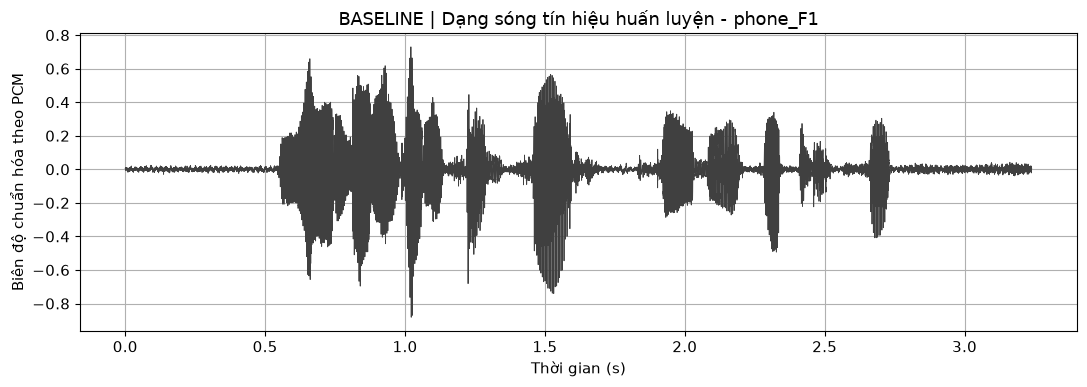

In [4]:
fig, ax = plt.subplots()
ax.plot(sample_times, audio.signal, color="0.25", linewidth=0.6)
ax.set(title=f"BASELINE | Dạng sóng tín hiệu huấn luyện - {audio.name}", xlabel="Thời gian (s)", ylabel="Biên độ chuẩn hóa theo PCM")
fig.tight_layout()
plt.show()


### 5. Chia tín hiệu thành các Frame

Dùng hàm chia Frame của project với độ dài 25 ms và bước dịch 10 ms.
Chỉ giữ các Frame đầy đủ; hàm trả về thời điểm tâm Frame và
độ dài, bước dịch tính theo số mẫu từ Fs thực tế.


In [5]:
frames = prepare_frames(audio, config)
print("Kích thước ma trận Frame:", frames.frames.shape)
print("Độ dài / bước dịch Frame (số mẫu):", frames.frame_len, frames.frame_shift)
print("Thời điểm tâm Frame đầu tiên (s):", frames.timestamps[0])


Kích thước ma trận Frame: (322, 400)
Độ dài / bước dịch Frame (số mẫu): 400 160
Thời điểm tâm Frame đầu tiên (s): 0.0125


### 6. Tính STE và MA

Cả hai đặc trưng đều dùng phép tính tổng trong các hàm của project:
mỗi Frame tạo ra đúng một giá trị đặc trưng.


In [6]:
ste = compute_ste(frames.frames)
ma = compute_ma(frames.frames)
assert len(ste) == len(ma) == len(frames.frames) == len(frames.timestamps)
assert np.all(ste >= 0) and np.all(ma >= 0)
print("Kích thước các mảng STE / MA:", ste.shape, ma.shape)


Kích thước các mảng STE / MA: (322,) (322,)


### 7. Trực quan hóa đặc trưng theo thời gian

So sánh thang giá trị của hai đặc trưng ban đầu.
Ngưỡng của đặc trưng này không thể dùng thay cho ngưỡng của đặc trưng kia.


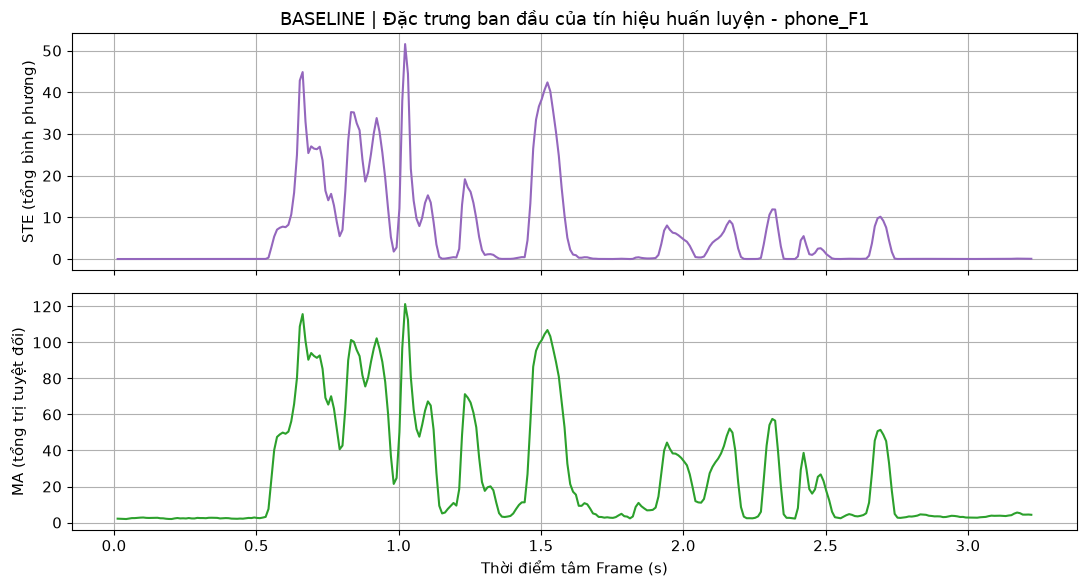

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(frames.timestamps, ste, color="tab:purple")
axes[0].set(title=f"BASELINE | Đặc trưng ban đầu của tín hiệu huấn luyện - {audio.name}", ylabel="STE (tổng bình phương)")
axes[1].plot(frames.timestamps, ma, color="tab:green")
axes[1].set(xlabel="Thời điểm tâm Frame (s)", ylabel="MA (tổng trị tuyệt đối)")
fig.tight_layout()
plt.show()


### 8. Tính logSTE và logMA

Dùng hàm biến đổi logarit tự nhiên của project với epsilon.
Lấy các giá trị đặc trưng từ pipeline, không bổ sung bước chuẩn hóa
đặc trưng riêng cho từng file.


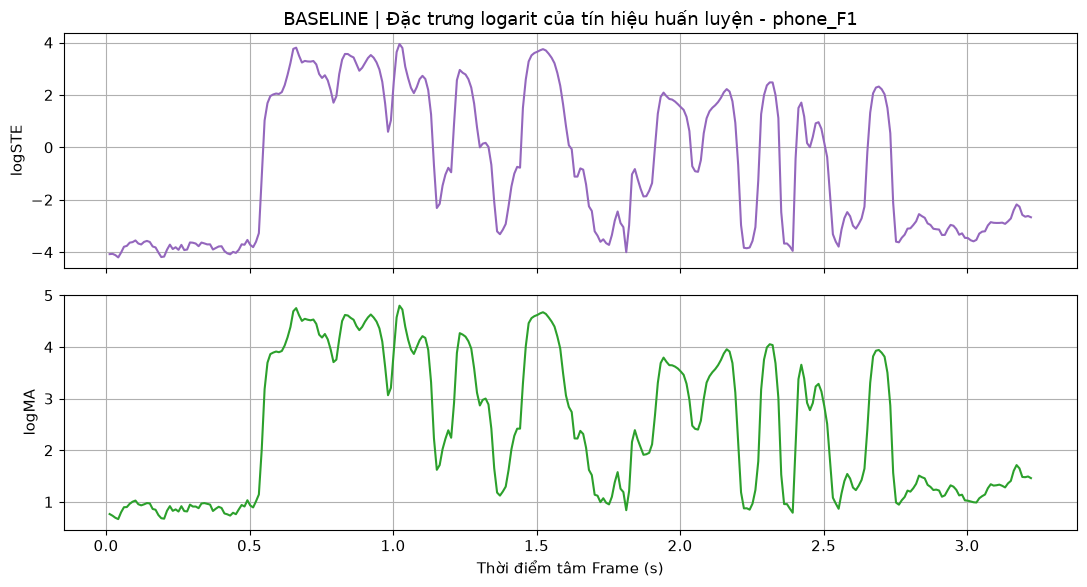

In [8]:
logste = log_transform(ste, config.epsilon)
logma = log_transform(ma, config.epsilon)
features = extract_features(frames, config)
expected_values = {"ste": ste, "ma": ma, "logste": logste, "logma": logma}[config.feature_type]
np.testing.assert_allclose(features.values, expected_values)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(frames.timestamps, logste, color="tab:purple")
axes[0].set(title=f"BASELINE | Đặc trưng logarit của tín hiệu huấn luyện - {audio.name}", ylabel="logSTE")
axes[1].plot(frames.timestamps, logma, color="tab:green")
axes[1].set(xlabel="Thời điểm tâm Frame (s)", ylabel="logMA")
fig.tight_layout()
plt.show()


### 9. Xây dựng Histogram ban đầu

Gộp đặc trưng đã chọn từ **tất cả** các file WAV thuộc tập huấn luyện,
sử dụng các hàm đọc tín hiệu, chia Frame và trích xuất đặc trưng của project.
Ngưỡng chung không được huấn luyện riêng cho từng file.
Các bước này không sử dụng file LAB.


In [9]:
training_vectors = []
training_summary = []
for path in training_paths:
    if path == wav_path:
        training_audio, training_frames, training_features = audio, frames, features
    else:
        training_audio = load_audio(path)
        training_frames = prepare_frames(training_audio, config)
        training_features = extract_features(training_frames, config)
    if not training_features.values.size:
        raise ValueError(f"Không có Frame đầy đủ trong {path.name}")
    training_vectors.append(training_features.values)
    training_summary.append((path.name, training_audio.fs, len(training_features.values)))
combined_features = np.concatenate(training_vectors)
histogram, bin_centers = build_histogram(combined_features, config.histogram_bins)
assert histogram.sum() == len(combined_features)
for name, fs, count in training_summary:
    print(f"{name:16s} Fs={fs:5d} Hz   số Frame={count}")
print("Tổng số Frame đã gộp:", len(combined_features), "| số bin Histogram:", len(histogram))


phone_F1.wav     Fs=16000 Hz   số Frame=322
phone_M1.wav     Fs=16000 Hz   số Frame=414
studio_F1.wav    Fs=44100 Hz   số Frame=284
studio_M1.wav    Fs=44100 Hz   số Frame=271
Tổng số Frame đã gộp: 1291 | số bin Histogram: 40


### 10. Làm mượt Histogram

Gọi hàm làm mượt được cài đặt thủ công trong project.
Ở các bin biên, cửa sổ chỉ lấy trung bình những bin lân cận hợp lệ.
Đồ thị dưới đây thể hiện Histogram ban đầu và Histogram sau khi làm mượt.


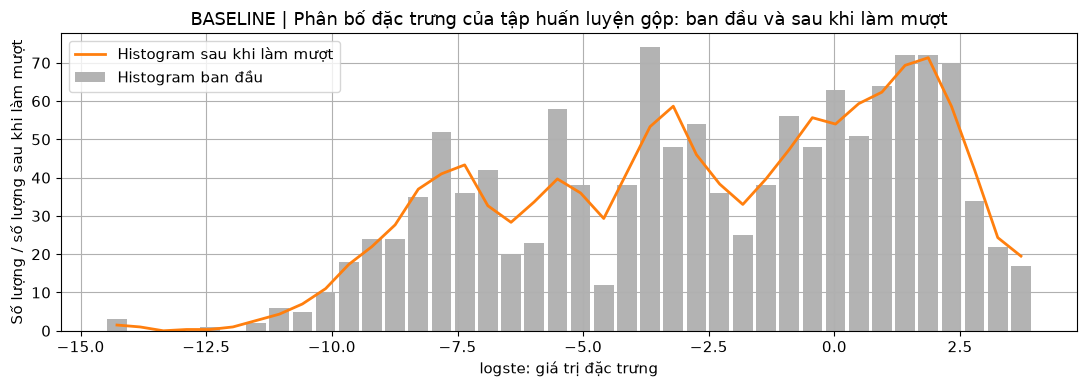

In [10]:
smoothed_histogram = smooth_histogram(histogram, config.histogram_smoothing_window)
assert smoothed_histogram.shape == histogram.shape
fig, ax = plt.subplots()
bar_width = (bin_centers[1] - bin_centers[0]) * 0.85 if len(bin_centers) > 1 else 1
ax.bar(bin_centers, histogram, width=bar_width, color="0.7", label="Histogram ban đầu")
ax.plot(bin_centers, smoothed_histogram, color="tab:orange", linewidth=2, label="Histogram sau khi làm mượt")
ax.set(title="BASELINE | Phân bố đặc trưng của tập huấn luyện gộp: ban đầu và sau khi làm mượt", xlabel=f"{config.feature_type}: giá trị đặc trưng", ylabel="Số lượng / số lượng sau khi làm mượt")
ax.legend()
fig.tight_layout()
plt.show()


### 11. Tìm các cực đại cục bộ

Hàm của project không chọn các bin đầu, cuối hoặc vùng đỉnh phẳng.
Chỉ số bin khác với vị trí trên trục đặc trưng;
số lượng trong bin là độ cao đỉnh, không phải M1/M2.


In [11]:
peak_indices = find_local_maxima(smoothed_histogram)
print("Chỉ số của tất cả cực đại cục bộ nghiêm ngặt:", peak_indices.tolist())
print("Vị trí cực đại trên trục đặc trưng:", bin_centers[peak_indices].tolist())
print("Độ cao của các cực đại:", smoothed_histogram[peak_indices].tolist())


Chỉ số của tất cả cực đại cục bộ nghiêm ngặt: [15, 19, 24, 30, 35]
Vị trí cực đại trên trục đặc trưng: [-7.357381141179487, -5.512433084493956, -3.206248013637042, -0.43882592860874503, 1.8673591422481692]
Độ cao của các cực đại: [43.33333333333333, 39.666666666666664, 58.66666666666667, 55.66666666666667, 71.33333333333333]


### 12. Chọn M1, M2 và tính ngưỡng baseline

Gọi các hàm chọn đỉnh và tính ngưỡng của project.
Với cấu hình mặc định, kết quả phải tái hiện baseline đã lưu từ tập huấn luyện gộp.
Đặc trưng theo thời gian thuộc file WAV đã chọn; Histogram gộp tất cả WAV huấn luyện.

**Đây là kết quả baseline / nghiên cứu, chưa phải mô hình cuối của `main.py`.**
Ngưỡng cuối T* được nạp riêng từ file khóa ở phần C.


BASELINE | M1=-3.206248, M2=1.867359, T=-1.515046
Dùng ngưỡng chung của cấu hình cơ sở đã lưu


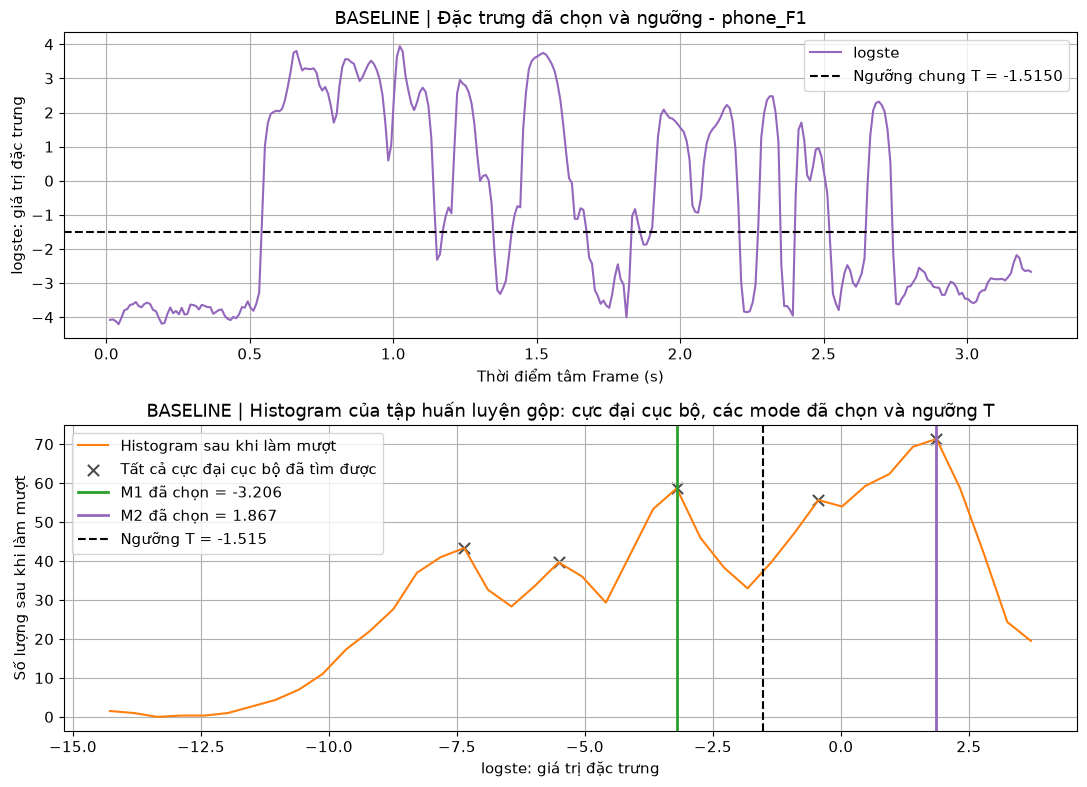

In [12]:
m1, m2 = select_two_peaks(smoothed_histogram, bin_centers, peak_indices,
                         min_peak_distance=min_peak_distance,
                         min_relative_height=min_relative_height)
research_threshold = calculate_threshold(m1, m2, weight)
if use_saved_baseline:
    if config.feature_type != saved_fit["feature"]:
        raise ValueError("Đặc trưng đã thay đổi: đặt use_saved_baseline=False để thử nghiệm chỉ trên tập huấn luyện.")
    active_parameters = {
        "frame_duration_ms": config.frame_duration_ms, "frame_shift_ms": config.frame_shift_ms,
        "epsilon": config.epsilon, "num_bins": config.histogram_bins,
        "smooth_window": config.histogram_smoothing_window, "weight": weight,
        "min_peak_distance": min_peak_distance, "min_relative_height": min_relative_height,
    }
    if active_parameters != parameters:
        raise ValueError("Tham số đã thay đổi: đặt use_saved_baseline=False để thử nghiệm chỉ trên tập huấn luyện.")
    np.testing.assert_allclose(research_threshold, saved_fit["threshold"], rtol=1e-12, atol=1e-12)
    threshold = float(saved_fit["threshold"])
else:
    threshold = research_threshold
print(f"BASELINE | M1={m1:.6f}, M2={m2:.6f}, T={threshold:.6f}")
print("Dùng ngưỡng chung của cấu hình cơ sở đã lưu" if use_saved_baseline else "Ngưỡng thử nghiệm trên tập huấn luyện; không lưu lại")

fig, axes = plt.subplots(2, 1, figsize=(11, 8))
axes[0].plot(features.timestamps, features.values, color="tab:purple", label=config.feature_type)
axes[0].axhline(threshold, color="black", linestyle="--", label=f"Ngưỡng chung T = {threshold:.4f}")
axes[0].set(title=f"BASELINE | Đặc trưng đã chọn và ngưỡng - {audio.name}", xlabel="Thời điểm tâm Frame (s)", ylabel=f"{config.feature_type}: giá trị đặc trưng")
axes[0].legend()
axes[1].plot(bin_centers, smoothed_histogram, color="tab:orange", label="Histogram sau khi làm mượt")
axes[1].scatter(bin_centers[peak_indices], smoothed_histogram[peak_indices], color="0.3", marker="x", s=65, label="Tất cả cực đại cục bộ đã tìm được")
axes[1].axvline(m1, color="tab:green", linewidth=2, label=f"M1 đã chọn = {m1:.3f}")
axes[1].axvline(m2, color="tab:purple", linewidth=2, label=f"M2 đã chọn = {m2:.3f}")
axes[1].axvline(threshold, color="black", linestyle="--", label=f"Ngưỡng T = {threshold:.3f}")
axes[1].set(title="BASELINE | Histogram của tập huấn luyện gộp: cực đại cục bộ, các mode đã chọn và ngưỡng T", xlabel=f"{config.feature_type}: giá trị đặc trưng", ylabel="Số lượng sau khi làm mượt")
axes[1].legend()
fig.tight_layout()
plt.show()


### 13. Phân loại Speech / Silence

Nhãn 0 là Silence; nhãn 1 là Speech. Dùng ngưỡng chung đã có,
không huấn luyện lại. Hàm hậu xử lý của project gộp các khoảng Silence
bên trong Speech ngắn hơn 200 ms, đồng thời giữ nguyên Silence ở đầu và cuối.
Thời điểm biên chuyển trạng thái là trung điểm giữa hai tâm Frame liên tiếp.


In [13]:
raw_labels = predict(features.values, threshold)
filtered_labels = merge_short_silences(raw_labels, frames.frame_shift * 1000 / frames.fs,
                                      min_silence_ms=config.min_silence_ms)
predicted_segments = decisions_to_segments(filtered_labels, features.timestamps, audio.duration_sec)
predicted_boundaries = segment_boundaries(predicted_segments)
assert len(raw_labels) == len(filtered_labels) == len(features.values)
print("Số biên chuyển trạng thái trước hậu xử lý:", len(segment_boundaries(decisions_to_segments(raw_labels, features.timestamps, audio.duration_sec))))
print("Biên dự đoán sau hậu xử lý (s):", predicted_boundaries)


Số biên chuyển trạng thái trước hậu xử lý: 16
Biên dự đoán sau hậu xử lý (s): [0.5375, 2.7375]


### 14. So sánh với nhãn thực tế từ file LAB

Đến bước này mới đọc file LAB. Ánh xạ `sil` thành Silence và `v`/`uv`
thành Speech; bỏ qua các dòng tổng hợp F0.
Biên kết quả dự đoán có màu **xanh dương**;
biên nhãn thực tế (Ground Truth) có màu **đỏ**.
Các tâm Frame không được LAB bao phủ giữ trạng thái chưa có nhãn.
Việc ghép biên dùng mức sai lệch cho phép cố định 100 ms đã được mô tả
và cùng loại chuyển trạng thái; các biên không ghép được vẫn được báo cáo
cùng MAE/RMSE.

Dùng các đồ thị huấn luyện này để xem xét Speech vô thanh bị bỏ sót,
biên dự đoán thừa, sự chồng lấn giữa các mode và chênh lệch
thời điểm kết thúc LAB/WAV. Tập kiểm thử không được sử dụng tại đây.
Đồ thị dưới đây thể hiện kết quả dự đoán cùng nhãn thực tế.


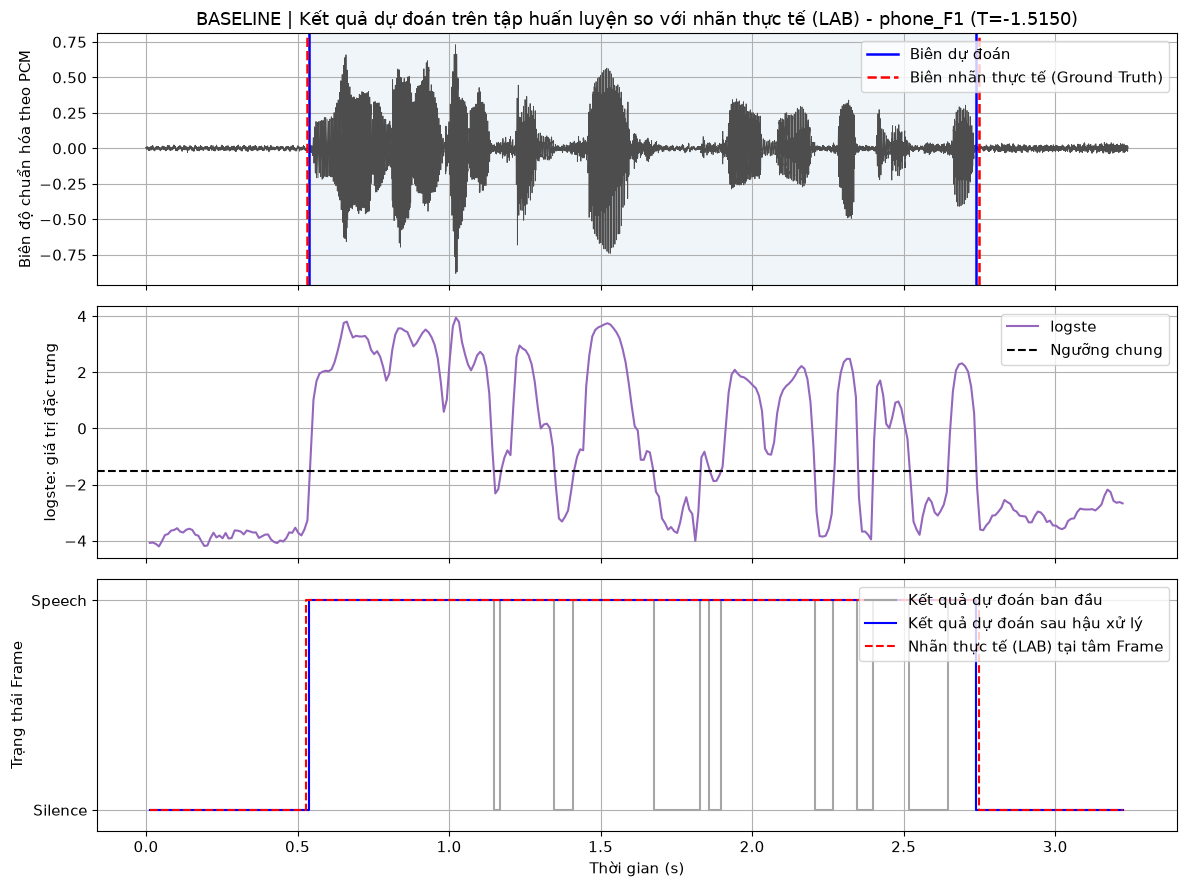

Biên nhãn thực tế (Ground Truth) (s): [0.53, 2.75]
Các cặp biên đã ghép (dự đoán, nhãn thực tế) (s): [(0.5375, 0.53), (2.7375, 2.75)]
Sai số thời gian có dấu (ms): [7.499999999999951, -12.500000000000178]
MAE=10.000 ms; RMSE=10.308 ms
Biên chưa ghép (dự đoán / nhãn thực tế): [] []
Số tâm Frame chưa có nhãn thực tế: 0
Chênh lệch thời điểm kết thúc (WAV - LAB): 10.000 ms
Đối chiếu nhãn thực tế (LAB) không làm thay đổi ngưỡng T: -1.5150456283419718


In [14]:
audio.gt_segments = parse_labels(wav_path.with_suffix(".lab"))
audio.gt_boundaries = speech_silence_boundaries(audio.gt_segments)
ground_truth_labels = labels_at_timestamps(audio.gt_segments, features.timestamps)
segmentation = SegmentationResult(audio.name, "histogram", threshold, features.timestamps,
                                  raw_labels, filtered_labels, predicted_boundaries, predicted_segments)
metrics = evaluate_result(audio, segmentation, tolerance_ms=boundary_tolerance_ms)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(sample_times, audio.signal, color="0.3", linewidth=0.6)
for start, end, label in predicted_segments:
    if label == "speech":
        axes[0].axvspan(start, end, color="tab:blue", alpha=0.07)
for i, time in enumerate(predicted_boundaries):
    axes[0].axvline(time, color="blue", linewidth=1.8, label="Biên dự đoán" if i == 0 else None)
for i, time in enumerate(audio.gt_boundaries):
    axes[0].axvline(time, color="red", linestyle="--", linewidth=1.8, label="Biên nhãn thực tế (Ground Truth)" if i == 0 else None)
axes[0].set(title=f"BASELINE | Kết quả dự đoán trên tập huấn luyện so với nhãn thực tế (LAB) - {audio.name} (T={threshold:.4f})", ylabel="Biên độ chuẩn hóa theo PCM")
axes[0].legend(loc="upper right")
axes[1].plot(features.timestamps, features.values, color="tab:purple", label=config.feature_type)
axes[1].axhline(threshold, color="black", linestyle="--", label="Ngưỡng chung")
axes[1].set(ylabel=f"{config.feature_type}: giá trị đặc trưng")
axes[1].legend(loc="upper right")
axes[2].step(features.timestamps, raw_labels, where="mid", color="0.65", label="Kết quả dự đoán ban đầu")
axes[2].step(features.timestamps, filtered_labels, where="mid", color="blue", label="Kết quả dự đoán sau hậu xử lý")
axes[2].step(features.timestamps, np.where(ground_truth_labels >= 0, ground_truth_labels, np.nan),
             where="mid", color="red", linestyle="--", label="Nhãn thực tế (LAB) tại tâm Frame")
axes[2].set(xlabel="Thời gian (s)", ylabel="Trạng thái Frame", yticks=[0, 1], yticklabels=["Silence", "Speech"], ylim=(-.1, 1.1))
axes[2].legend(loc="upper right")
fig.tight_layout()
plt.show()

print("Biên nhãn thực tế (Ground Truth) (s):", metrics.gt_boundaries)
print("Các cặp biên đã ghép (dự đoán, nhãn thực tế) (s):", metrics.matched_pairs)
print("Sai số thời gian có dấu (ms):", metrics.errors_ms)
print(f"MAE={metrics.mae_ms:.3f} ms; RMSE={metrics.rmse_ms:.3f} ms")
print("Biên chưa ghép (dự đoán / nhãn thực tế):", metrics.unmatched_predicted_boundaries, metrics.unmatched_gt_boundaries)
print("Số tâm Frame chưa có nhãn thực tế:", int(np.sum(ground_truth_labels == -1)))
print(f"Chênh lệch thời điểm kết thúc (WAV - LAB): {(audio.duration_sec - audio.gt_segments[-1].end) * 1000:.3f} ms")
print("Đối chiếu nhãn thực tế (LAB) không làm thay đổi ngưỡng T:", threshold)


## B. Thử nghiệm tham số — chỉ trên tập huấn luyện

Đọc lại `output/training/histogram_parameter_experiments.json`;
không chạy lại các thử nghiệm hoặc chọn tham số trong notebook.
Mỗi giai đoạn thay đổi một yếu tố: đặc trưng, số bin, cửa sổ làm mượt, trọng số W.

Bảng báo cáo MAE/RMSE trên các cặp biên đã ghép cùng số biên bỏ sót và biên thừa.
MAE thấp hơn trên các cặp đã ghép chưa đủ để kết luận cấu hình tốt hơn nếu bỏ sót
nhiều biên. Dấu ★ đánh dấu cấu hình được chọn trong báo cáo thử nghiệm đã lưu.
Mô hình cuối vẫn được lấy trực tiếp từ file khóa ở phần C.


In [15]:
experiment_path = root / "output/training/histogram_parameter_experiments.json"
experiment_report = json.loads(experiment_path.read_text(encoding="utf-8"))
if experiment_report["scope"] != "training_only":
    raise ValueError("Chỉ được dùng báo cáo thử nghiệm trên tập huấn luyện.")

stage_names = {
    "feature": "Đặc trưng", "num_bins": "Số bin",
    "smooth_window": "Cửa sổ làm mượt", "weight": "Trọng số W",
}
experiment_table = [
    "| Giai đoạn | Cấu hình | Đặc trưng | Bin | Window | W | Ngưỡng | MAE (ms) | RMSE (ms) | Ghép/GT | Bỏ sót | Thừa | Trạng thái |",
    "|---|---|---|---:|---:|---:|---:|---:|---:|---|---:|---:|---|",
]
for row in experiment_report["results"]:
    selected_mark = " ★" if row["configuration_id"] == experiment_report["selected_configuration_id"] else ""
    numbers = ["—" if row.get(key) is None else f"{row[key]:.6f}"
               for key in ("threshold", "training_mae_ms", "training_rmse_ms")]
    status_text = "Thành công" if row["status"] == "ok" else str(row.get("failure_status") or "Thất bại")
    experiment_table.append(
        f"| {stage_names[row['stage']]} | {row['configuration_id']}{selected_mark} | {row['feature']} | "
        f"{row['num_bins']} | {row['smooth_window']} | {row['weight']:g} | "
        f"{numbers[0]} | {numbers[1]} | {numbers[2]} | "
        f"{row.get('matched_count', '—')}/{row.get('gt_count', '—')} | "
        f"{row.get('unmatched_gt_count', '—')} | {row.get('unmatched_predicted_count', '—')} | {status_text} |"
    )
display(Markdown("\n".join(experiment_table)))
print("Số cấu hình huấn luyện riêng biệt:", experiment_report["number_of_unique_fits"])
print("Số lượt ghi nhận theo giai đoạn:", experiment_report["number_of_stage_observations"])
print("Chỉ hiển thị kết quả đã lưu; không tìm kiếm hoặc huấn luyện lại.")


| Giai đoạn | Cấu hình | Đặc trưng | Bin | Window | W | Ngưỡng | MAE (ms) | RMSE (ms) | Ghép/GT | Bỏ sót | Thừa | Trạng thái |
|---|---|---|---:|---:|---:|---:|---:|---:|---|---:|---:|---|
| Đặc trưng | config_01 | logste | 40 | 3 | 2 | -1.515046 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Đặc trưng | config_02 | ste | 40 | 3 | 2 | 21.702063 | 67.494331 | 67.494331 | 1/8 | 7 | 5 | Thành công |
| Đặc trưng | config_03 | ma | 40 | 3 | 2 | 37.937286 | 31.498866 | 35.301223 | 5/8 | 3 | 9 | Thành công |
| Đặc trưng | config_04 | logma | 40 | 3 | 2 | 0.352652 | 23.333333 | 32.754253 | 6/8 | 2 | 2 | Thành công |
| Số bin | config_01 | logste | 40 | 3 | 2 | -1.515046 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Số bin | config_05 | logste | 20 | 3 | 2 | -1.745664 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Số bin | config_06 | logste | 30 | 3 | 2 | -1.489421 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Số bin | config_07 | logste | 50 | 3 | 2 | -1.653417 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Số bin | config_08 | logste | 60 | 3 | 2 | -1.745664 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Cửa sổ làm mượt | config_01 | logste | 40 | 3 | 2 | -1.515046 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Cửa sổ làm mượt | config_09 ★ | logste | 40 | 1 | 2 | -2.437520 | 10.626417 | 17.852381 | 8/8 | 0 | 2 | Thành công |
| Cửa sổ làm mượt | config_10 | logste | 40 | 5 | 2 | -1.668791 | 14.376417 | 20.309399 | 8/8 | 0 | 2 | Thành công |
| Cửa sổ làm mượt | config_11 | logste | 40 | 7 | 2 | -1.207554 | 16.876417 | 21.212870 | 8/8 | 0 | 6 | Thành công |
| Trọng số W | config_09 ★ | logste | 40 | 1 | 2 | -2.437520 | 10.626417 | 17.852381 | 8/8 | 0 | 2 | Thành công |
| Trọng số W | config_12 | logste | 40 | 1 | 1 | -1.822537 | 13.126417 | 19.201758 | 8/8 | 0 | 2 | Thành công |
| Trọng số W | config_13 | logste | 40 | 1 | 3 | -2.745011 | 12.500000 | 19.247622 | 7/8 | 1 | 2 | Thành công |
| Trọng số W | config_14 | logste | 40 | 1 | 5 | -3.052502 | 8.928571 | 9.954444 | 7/8 | 1 | 0 | Thành công |

Số cấu hình huấn luyện riêng biệt: 14
Số lượt ghi nhận theo giai đoạn: 17
Chỉ hiển thị kết quả đã lưu; không tìm kiếm hoặc huấn luyện lại.


## C. Cấu hình Histogram cuối đã khóa — cùng mô hình với main.py

Dùng `load_frozen_histogram()` từ `src.config`, đúng API và file mà `main.py`
đang sử dụng. Các tham số, M1, M2, T* và dữ liệu debug đều được nạp từ
`output/training/final_histogram_configuration.json`; không sao chép giá trị
cố định và không tính lại ngưỡng.

Các biến có tiền tố `final_` thuộc mô hình cuối; `config`, `threshold`
và các biến của phần A vẫn thuộc baseline / nghiên cứu.
Nếu cửa sổ làm mượt cuối bằng 1, hàm làm mượt giữ nguyên Histogram ban đầu.
Làm mượt đã được cài đặt và khảo sát ở baseline, nhưng cấu hình cuối này
không làm thay đổi các số lượng trong Histogram.


In [16]:
final_lock_path = root / "output/training/final_histogram_configuration.json"
final_config, final_model, final_information = load_frozen_histogram(final_lock_path)
final_parameters = dict(final_information["parameters"])
final_m1 = final_information["m1"]
final_m2 = final_information["m2"]
final_threshold = final_model.value

final_histogram = final_model.debug["histogram"]
final_smoothed_histogram = final_model.debug["smoothed_histogram"]
final_bin_centers = final_model.debug["bin_centers"]
final_peak_indices = final_model.debug["peak_indices"]
assert final_model.feature_type == final_config.feature_type == final_information["feature"]
assert final_config.histogram_bins == final_parameters["num_bins"]
assert final_config.histogram_smoothing_window == final_parameters["smooth_window"]
assert final_m1 == final_model.debug["m1"] and final_m2 == final_model.debug["m2"]
assert final_m1 < final_threshold < final_m2
assert len(final_histogram) == len(final_smoothed_histogram) == len(final_bin_centers) == final_parameters["num_bins"]

print("MÔ HÌNH HISTOGRAM CUỐI ĐÃ KHÓA — cùng nguồn với main.py")
print("Nguồn:", final_lock_path.relative_to(root))
print("feature =", final_config.feature_type)
print("num_bins =", final_parameters["num_bins"])
print("smooth_window =", final_parameters["smooth_window"])
print("W =", final_parameters["weight"])
print("M1 =", final_m1)
print("M2 =", final_m2)
print("T* =", final_threshold)
print("Frame / bước dịch (ms):", final_config.frame_duration_ms, "/", final_config.frame_shift_ms)
print("Khoảng Silence nội bộ tối thiểu (ms):", final_config.min_silence_ms)
print("Cấu hình đã chọn từ tập huấn luyện:", final_information["selected_configuration_id"])
print("Số WAV / tổng Frame huấn luyện:", final_information["number_of_wavs"], "/", final_information["total_combined_frames"])
if final_parameters["smooth_window"] == 1:
    np.testing.assert_array_equal(final_smoothed_histogram, final_histogram)
    print("Window = 1: Histogram sau khi làm mượt trùng Histogram ban đầu; không thay đổi số lượng trong các bin.")


MÔ HÌNH HISTOGRAM CUỐI ĐÃ KHÓA — cùng nguồn với main.py
Nguồn: output\training\final_histogram_configuration.json
feature = logste
num_bins = 40
smooth_window = 1
W = 2.0
M1 = -3.667485027808425
M2 = 0.022411085562637822
T* = -2.4375196566847372
Frame / bước dịch (ms): 25.0 / 10.0
Khoảng Silence nội bộ tối thiểu (ms): 200.0
Cấu hình đã chọn từ tập huấn luyện: config_09
Số WAV / tổng Frame huấn luyện: 4 / 1291
Window = 1: Histogram sau khi làm mượt trùng Histogram ban đầu; không thay đổi số lượng trong các bin.


## D. Kiểm chứng mô hình cuối trên tập huấn luyện

Gọi `evaluate_histogram_on_training_set()` bằng `final_config` và
`final_model` đã khóa. Hàm dùng các bước đọc WAV, chia Frame, trích xuất
đặc trưng, dự đoán, hậu xử lý và đánh giá biên của project.
Mỗi WAV dùng cùng T*; LAB chỉ dùng để đánh giá sau dự đoán.

Đối chiếu kết quả với `output/training/histogram_final_training_evaluation.json`
và thông tin huấn luyện trong file khóa. Việc đối chiếu không thay đổi
tham số hoặc ngưỡng. Bảng dưới đây thuộc **tập huấn luyện**, không phải tập kiểm thử.


In [17]:
final_saved_evaluation_path = root / "output/training/histogram_final_training_evaluation.json"
final_saved_evaluation = json.loads(final_saved_evaluation_path.read_text(encoding="utf-8"))
assert final_saved_evaluation["threshold"] == final_threshold
assert final_saved_evaluation["feature"] == final_config.feature_type

final_evaluation = evaluate_histogram_on_training_set(
    training_directory, final_model, final_config,
    tolerance_ms=final_information["evaluation_tolerance_ms"],
)
final_rows_by_name = {row["wav"]: row for row in final_evaluation["files"]}
final_saved_rows_by_name = {row["wav"]: row for row in final_saved_evaluation["files"]}
assert sorted(final_rows_by_name) == sorted(row["wav"] for row in final_information["files"])
assert sorted(final_rows_by_name) == sorted(final_saved_rows_by_name)
assert sum(row["frames"] for row in final_evaluation["files"]) == final_information["total_combined_frames"]

final_training_table = [
    "| WAV huấn luyện | Fs (Hz) | Frame | Ghép/GT | Thừa | Bỏ sót | MAE (ms) | RMSE (ms) |",
    "|---|---:|---:|---|---:|---:|---:|---:|",
]
for row in final_evaluation["files"]:
    saved_row = final_saved_rows_by_name[row["wav"]]
    assert row["threshold"] == final_threshold
    for key in ("raw_predicted_frame_labels", "predicted_frame_labels", "ground_truth_frame_labels"):
        np.testing.assert_array_equal(row[key], saved_row[key])
    for key in ("timestamps_sec", "feature_values", "predicted_boundaries", "ground_truth_boundaries"):
        np.testing.assert_allclose(row[key], saved_row[key], rtol=1e-12, atol=1e-12)
    evaluation = row["boundary_evaluation"]
    np.testing.assert_allclose(
        [evaluation["mae_ms"], evaluation["rmse_ms"]],
        [saved_row["boundary_evaluation"]["mae_ms"], saved_row["boundary_evaluation"]["rmse_ms"]],
        rtol=1e-12, atol=1e-12,
    )
    final_training_table.append(
        f"| {row['wav']} | {row['fs']} | {row['frames']} | "
        f"{evaluation['matched_count']}/{evaluation['gt_count']} | "
        f"{len(evaluation['unmatched_predicted_boundaries'])} | {len(evaluation['unmatched_gt_boundaries'])} | "
        f"{evaluation['mae_ms']:.6f} | {evaluation['rmse_ms']:.6f} |"
    )
display(Markdown("\n".join(final_training_table)))
final_matched_pairs = [
    pair for row in final_evaluation["files"]
    for pair in row["boundary_evaluation"]["matched_pairs_sec"]
]
final_training_mae = boundary_mae_ms(final_matched_pairs)
final_training_rmse = boundary_rmse_ms(final_matched_pairs)
np.testing.assert_allclose(
    [final_training_mae, final_training_rmse],
    [final_information["training_metrics"]["training_mae_ms"], final_information["training_metrics"]["training_rmse_ms"]],
    rtol=1e-12, atol=1e-12,
)
print(f"MAE huấn luyện gộp = {final_training_mae:.6f} ms; RMSE = {final_training_rmse:.6f} ms")
print("Kết quả khớp báo cáo huấn luyện cuối đã lưu; ngưỡng T* giữ nguyên:", final_threshold)


| WAV huấn luyện | Fs (Hz) | Frame | Ghép/GT | Thừa | Bỏ sót | MAE (ms) | RMSE (ms) |
|---|---:|---:|---|---:|---:|---:|---:|
| phone_F1.wav | 16000 | 322 | 2/2 | 2 | 0 | 5.000000 | 5.590170 |
| phone_M1.wav | 16000 | 414 | 2/2 | 0 | 0 | 5.000000 | 5.590170 |
| studio_F1.wav | 44100 | 284 | 2/2 | 0 | 0 | 2.505669 | 2.505669 |
| studio_M1.wav | 44100 | 271 | 2/2 | 0 | 0 | 30.000000 | 34.728254 |

MAE huấn luyện gộp = 10.626417 ms; RMSE = 17.852381 ms
Kết quả khớp báo cáo huấn luyện cuối đã lưu; ngưỡng T* giữ nguyên: -2.4375196566847372


### Trực quan hóa kết quả huấn luyện cuối đã khóa

Dạng sóng và đặc trưng theo thời gian thuộc WAV huấn luyện đã chọn.
Biên dự đoán màu xanh dương; biên nhãn thực tế màu đỏ.
Đường ngưỡng dùng T* đã nạp, không dùng ngưỡng baseline.

Histogram và các cực đại cục bộ được lấy từ dữ liệu debug của mô hình cuối:
đây là phân bố gộp của tất cả WAV huấn luyện. M1/M2 là vị trí trên trục
đặc trưng. Với window 1, Histogram sau khi làm mượt trùng Histogram ban đầu;
đồ thị không thể hiện một tác động làm mượt mới.


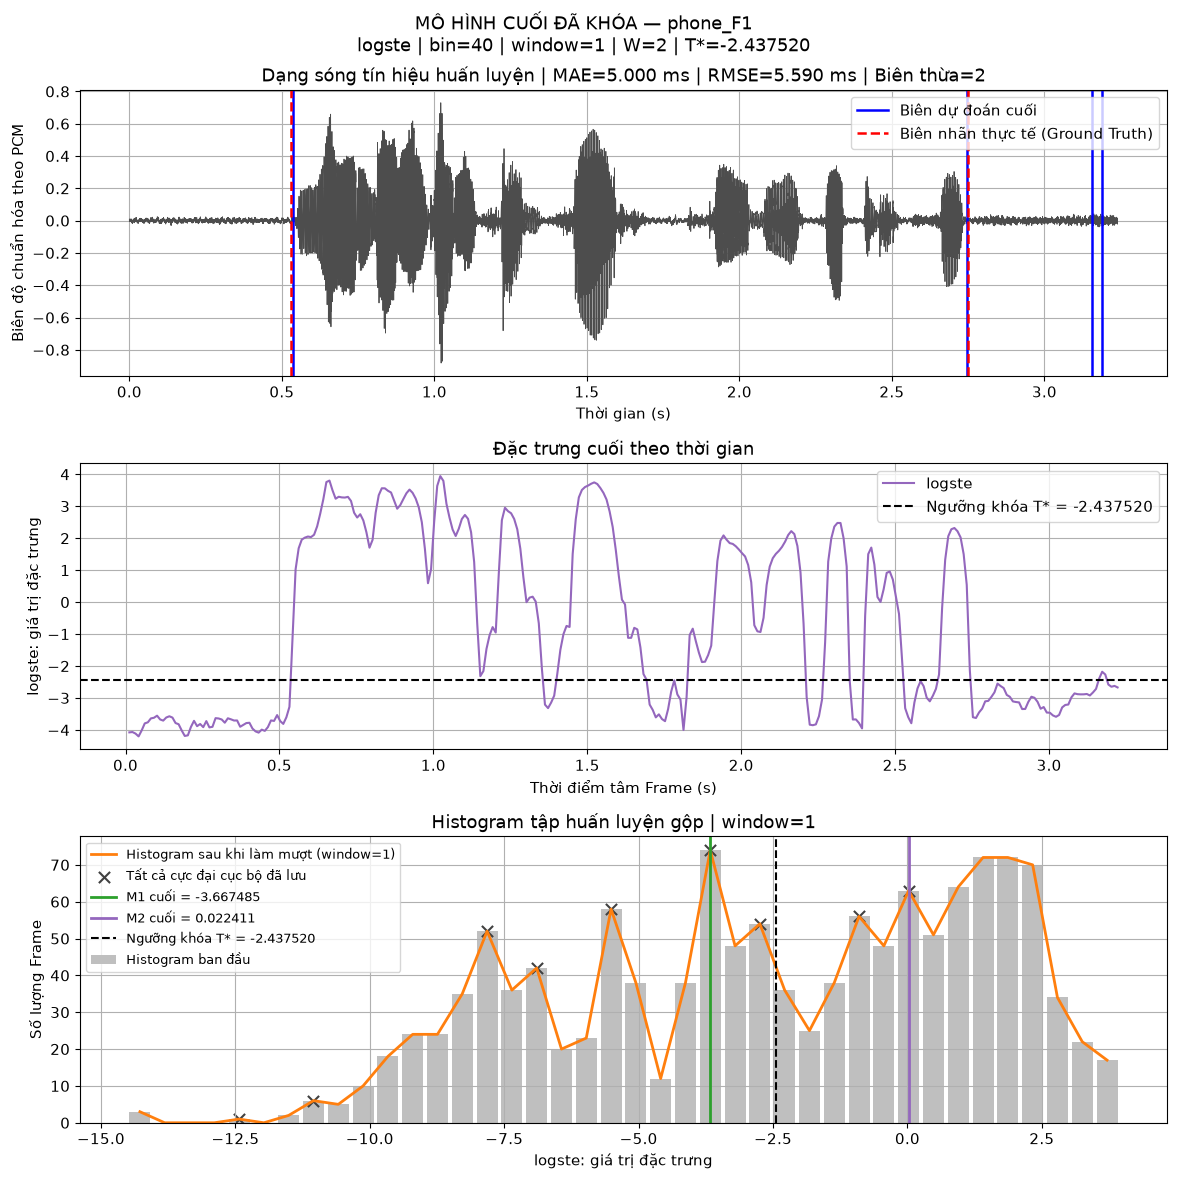

In [18]:
final_recording = final_rows_by_name[wav_path.name]
assert final_recording["fs"] == audio.fs
final_timestamps = np.asarray(final_recording["timestamps_sec"])
final_feature_values = np.asarray(final_recording["feature_values"])
final_boundaries = final_recording["predicted_boundaries"]
final_gt_boundaries = final_recording["ground_truth_boundaries"]
final_recording_metrics = final_recording["boundary_evaluation"]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle(
    f"MÔ HÌNH CUỐI ĐÃ KHÓA — {audio.name}\n"
    f"{final_config.feature_type} | bin={final_parameters['num_bins']} | window={final_parameters['smooth_window']} | "
    f"W={final_parameters['weight']:g} | T*={final_threshold:.6f}",
    fontsize=13,
)
axes[0].plot(sample_times, audio.signal, color="0.3", linewidth=0.6)
for i, time in enumerate(final_boundaries):
    axes[0].axvline(time, color="blue", linewidth=1.8, label="Biên dự đoán cuối" if i == 0 else None)
for i, time in enumerate(final_gt_boundaries):
    axes[0].axvline(time, color="red", linestyle="--", linewidth=1.8,
                   label="Biên nhãn thực tế (Ground Truth)" if i == 0 else None)
axes[0].set(
    title=f"Dạng sóng tín hiệu huấn luyện | MAE={final_recording_metrics['mae_ms']:.3f} ms | "
          f"RMSE={final_recording_metrics['rmse_ms']:.3f} ms | Biên thừa={len(final_recording_metrics['unmatched_predicted_boundaries'])}",
    xlabel="Thời gian (s)", ylabel="Biên độ chuẩn hóa theo PCM",
)
axes[0].legend(loc="upper right")
axes[1].plot(final_timestamps, final_feature_values, color="tab:purple", label=final_config.feature_type)
axes[1].axhline(final_threshold, color="black", linestyle="--", label=f"Ngưỡng khóa T* = {final_threshold:.6f}")
axes[1].set(title="Đặc trưng cuối theo thời gian", xlabel="Thời điểm tâm Frame (s)",
            ylabel=f"{final_config.feature_type}: giá trị đặc trưng")
axes[1].legend(loc="upper right")
final_bar_width = (final_bin_centers[1] - final_bin_centers[0]) * 0.85
axes[2].bar(final_bin_centers, final_histogram, width=final_bar_width, color="0.75", label="Histogram ban đầu")
axes[2].plot(final_bin_centers, final_smoothed_histogram, color="tab:orange", linewidth=2,
             label=f"Histogram sau khi làm mượt (window={final_parameters['smooth_window']})")
axes[2].scatter(final_bin_centers[final_peak_indices], final_smoothed_histogram[final_peak_indices],
                color="0.25", marker="x", s=65, label="Tất cả cực đại cục bộ đã lưu")
axes[2].axvline(final_m1, color="tab:green", linewidth=2, label=f"M1 cuối = {final_m1:.6f}")
axes[2].axvline(final_m2, color="tab:purple", linewidth=2, label=f"M2 cuối = {final_m2:.6f}")
axes[2].axvline(final_threshold, color="black", linestyle="--", label=f"Ngưỡng khóa T* = {final_threshold:.6f}")
axes[2].set(
    title=f"Histogram tập huấn luyện gộp | window={final_parameters['smooth_window']}",
    xlabel=f"{final_config.feature_type}: giá trị đặc trưng", ylabel="Số lượng Frame",
)
axes[2].legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()


### Đối chiếu cuối cùng với mô hình main.py

Nạp lại mô hình qua cùng API để kiểm tra cấu hình, M1/M2/T* và file khóa
vẫn giữ nguyên sau khi trực quan hóa và đánh giá huấn luyện.
Các giá trị được in cuối notebook dưới đây là **mô hình cuối đã khóa**.
Phần A chỉ giữ vai trò minh họa baseline; notebook không ghi đè
file khóa, không huấn luyện lại mô hình cuối và không đọc tập kiểm thử.


In [19]:
production_config, production_model, production_information = load_frozen_histogram(final_lock_path)
assert final_config == production_config
assert final_parameters == production_information["parameters"]
assert final_model.feature_type == production_model.feature_type
assert final_threshold == final_model.value == production_model.value
assert final_m1 == production_information["m1"] and final_m2 == production_information["m2"]
assert final_information["lock_sha256"] == production_information["lock_sha256"]

print("KẾT QUẢ CUỐI: KHỚP MÔ HÌNH ĐÃ KHÓA CỦA main.py")
print("feature =", final_config.feature_type)
print("num_bins =", final_parameters["num_bins"])
print("smooth_window =", final_parameters["smooth_window"])
print("W =", final_parameters["weight"])
print("M1 =", final_m1)
print("M2 =", final_m2)
print("T* =", final_threshold)
print("Chỉ đọc tập huấn luyện; file khóa và tham số giữ nguyên.")


KẾT QUẢ CUỐI: KHỚP MÔ HÌNH ĐÃ KHÓA CỦA main.py
feature = logste
num_bins = 40
smooth_window = 1
W = 2.0
M1 = -3.667485027808425
M2 = 0.022411085562637822
T* = -2.4375196566847372
Chỉ đọc tập huấn luyện; file khóa và tham số giữ nguyên.
